# NB06: Experimental Prioritization

**Goal**: Rank truly dark genes for experimental follow-up using multi-criteria scoring. Produce a top-50-100 candidate list with functional hypotheses and experimental predictions.

**Input**: All data from NB01-NB05

**Output**: `data/prioritized_truly_dark_candidates.tsv`, top candidate table, summary figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

OUT = '../data'
FIG = '../figures'
os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 1. Load and Merge All Data

In [2]:
# Core data
td = pd.read_csv(f'{OUT}/truly_dark_genes.tsv', sep='\t')
clue = pd.read_csv(f'{OUT}/truly_dark_clue_matrix.tsv', sep='\t')
context = pd.read_csv(f'{OUT}/genomic_context.tsv', sep='\t')
gene_props = pd.read_csv(f'{OUT}/gene_properties.tsv', sep='\t')
eggnog = pd.read_csv(f'{OUT}/truly_dark_eggnog.tsv', sep='\t')
pfam = pd.read_csv(f'{OUT}/truly_dark_pfam.tsv', sep='\t')

print(f'Truly dark genes: {len(td):,}')
print(f'Clue matrix: {len(clue):,}')
print(f'Genomic context: {len(context):,}')

# Merge clue and context
clue['locusId'] = clue['locusId'].astype(str)
context['locusId'] = context['locusId'].astype(str)
td['locusId'] = td['locusId'].astype(str)

# Start from clue matrix and add context columns
candidates = clue.merge(
    context[['orgId', 'locusId', 'near_mobile_element', 'max_cofitness', 
             'in_operon', 'operon_partner_desc', 'frac_hyp_neighbors']],
    on=['orgId', 'locusId'], how='left'
)
print(f'Merged candidates: {len(candidates):,}')

Truly dark genes: 6,427
Clue matrix: 6,427
Genomic context: 6,427
Merged candidates: 6,427


## 2. Multi-Criteria Scoring

Score each gene on 5 axes:
1. **Fitness importance** (0-3): essential=3, |f|>=2=2, |f|>=1=1, else 0
2. **Annotation clues** (0-3): n_clues >= 5 → 3, >= 3 → 2, >= 1 → 1, 0 → 0
3. **Ortholog breadth** (0-2): >= 3 orgs → 2, >= 1 → 1, 0 → 0
4. **Genomic context** (0-2): in operon → 1, near mobile → 1
5. **Tractability** (0-2): well-studied organism → 2, ICA organism → 1, else 0

In [3]:
# Well-studied organisms for genetics
WELL_STUDIED = ['DvH', 'MR1', 'Keio', 'SynE', 'Putida', 'Caulo', 'Btheta', 'PV4']
ICA_ORGS = set(candidates[candidates['in_module'].fillna(False)]['orgId'].unique())

def score_fitness(row):
    if row.get('is_essential', False) or row.get('is_essential_dark', False):
        return 3
    elif row.get('max_abs_fit', 0) >= 2.0:
        return 2
    elif row.get('max_abs_fit', 0) >= 1.0:
        return 1
    return 0

def score_clues(row):
    n = row.get('n_clues', 0)
    if n >= 5: return 3
    elif n >= 3: return 2
    elif n >= 1: return 1
    return 0

def score_orthologs(row):
    n = row.get('n_ortholog_orgs', 0)
    if n >= 3: return 2
    elif n >= 1: return 1
    return 0

def score_context(row):
    s = 0
    if row.get('in_operon', False): s += 1
    if row.get('near_mobile_element', False): s += 1
    return s

def score_tractability(row):
    if row['orgId'] in WELL_STUDIED: return 2
    elif row['orgId'] in ICA_ORGS: return 1
    return 0

candidates['score_fitness'] = candidates.apply(score_fitness, axis=1)
candidates['score_clues'] = candidates.apply(score_clues, axis=1)
candidates['score_orthologs'] = candidates.apply(score_orthologs, axis=1)
candidates['score_context'] = candidates.apply(score_context, axis=1)
candidates['score_tractability'] = candidates.apply(score_tractability, axis=1)

# Total score (max = 12)
score_cols = ['score_fitness', 'score_clues', 'score_orthologs', 'score_context', 'score_tractability']
candidates['priority_score'] = candidates[score_cols].sum(axis=1)

print(f'Priority score distribution:')
print(candidates['priority_score'].describe().to_string())
print(f'\nScore breakdown:')
for col in score_cols:
    print(f'  {col}: mean={candidates[col].mean():.2f}')

print(f'\nTop scores:')
print(candidates['priority_score'].value_counts().sort_index(ascending=False).head(10).to_string())

Priority score distribution:
count    6427.000000
mean        4.134744
std         1.880797
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        10.000000

Score breakdown:
  score_fitness: mean=1.06
  score_clues: mean=1.64
  score_orthologs: mean=0.35
  score_context: mean=0.22
  score_tractability: mean=0.86

Top scores:
priority_score
10       6
9       43
8      255
7      414
6      829
5     1131
4     1164
3     1268
2      832
1      436


## 3. Top Candidates

In [4]:
# Sort by priority score, break ties by max_abs_fit
candidates = candidates.sort_values(['priority_score', 'max_abs_fit'], ascending=[False, False])

# Top 50
top50 = candidates.head(50).copy()

# Build functional hypothesis from available clues
def build_hypothesis(row):
    clues = []
    if row.get('pfam_names') and pd.notna(row.get('pfam_names')):
        clues.append(f'Pfam: {str(row["pfam_names"])[:80]}')
    if row.get('cog_category') and pd.notna(row.get('cog_category')) and str(row['cog_category']) not in ['-', 'S', '']:
        clues.append(f'COG: {row["cog_category"]}')
    if row.get('description') and pd.notna(row.get('description')) and str(row['description']) != '-':
        clues.append(f'eggNOG: {str(row["description"])[:60]}')
    if row.get('in_operon', False) and pd.notna(row.get('operon_partner_desc')):
        clues.append(f'Operon with: {str(row["operon_partner_desc"])[:50]}')
    if row.get('in_module', False) and row.get('module_ids') and pd.notna(row.get('module_ids')):
        clues.append(f'ICA module: {row["module_ids"]}')
    if row.get('near_mobile_element', False):
        clues.append('Near mobile element')
    if not clues:
        clues.append('No functional clues — pure fitness-driven candidate')
    return '; '.join(clues)

top50['hypothesis'] = top50.apply(build_hypothesis, axis=1)

print(f'Top 50 candidates (score range: {top50["priority_score"].min()}-{top50["priority_score"].max()}):')
print(f'  Organisms: {top50["orgId"].nunique()}')
print(f'  Essential: {top50["is_essential"].sum()}')
print(f'  In operons: {top50["in_operon"].fillna(False).sum()}')
print(f'  With Pfam: {top50["has_pfam"].sum()}')
print(f'  In modules: {top50["in_module"].sum()}')

Top 50 candidates (score range: 8-10):
  Organisms: 14
  Essential: 34
  In operons: 11
  With Pfam: 2
  In modules: 10


In [5]:
# Display top 30 in detail
display_cols = ['orgId', 'locusId', 'priority_score', 'max_abs_fit', 
                'top_condition_class', 'est_aa_length', 'n_clues', 'tier',
                'n_ortholog_orgs', 'hypothesis']

print('\nTop 30 Truly Dark Gene Candidates for Experimental Characterization:')
print('=' * 120)
for rank, (_, row) in enumerate(top50.head(30).iterrows(), 1):
    essential = ' [ESSENTIAL]' if row.get('is_essential', False) or row.get('is_essential_dark', False) else ''
    operon = ' [OPERON]' if row.get('in_operon', False) else ''
    mobile = ' [MOBILE]' if row.get('near_mobile_element', False) else ''
    
    print(f'\n#{rank:2d} | {row["orgId"]} / {row["locusId"]} | Score: {row["priority_score"]}{essential}{operon}{mobile}')
    print(f'     Fitness: |f|={row["max_abs_fit"]:.1f} in {row.get("top_condition_class", "?")}')
    print(f'     Size: {row["est_aa_length"]:.0f} aa | Orthologs: {int(row.get("n_ortholog_orgs", 0))} orgs | Clues: {row["n_clues"]}')
    print(f'     Hypothesis: {row["hypothesis"][:120]}')


Top 30 Truly Dark Gene Candidates for Experimental Characterization:

# 1 | PV4 / 5210953 | Score: 10 [OPERON]
     Fitness: |f|=5.5 in motility
     Size: 175 aa | Orthologs: 5 orgs | Clues: 6
     Hypothesis: Operon with: Sec-independent protein translocase, TatC subunit ; ICA module: M016

# 2 | MR1 / 203778 | Score: 10 [OPERON] [MOBILE]
     Fitness: |f|=3.6 in carbon source
     Size: 48 aa | Orthologs: 1 orgs | Clues: 5
     Hypothesis: Operon with: conserved hypothetical protein (NCBI ptt file); Near mobile element

# 3 | Putida / PP_2706 | Score: 10 [ESSENTIAL]
     Fitness: |f|=nan in nan
     Size: 83 aa | Orthologs: 3 orgs | Clues: 5
     Hypothesis: No functional clues — pure fitness-driven candidate

# 4 | PV4 / 5209493 | Score: 10 [ESSENTIAL]
     Fitness: |f|=nan in nan
     Size: 61 aa | Orthologs: 3 orgs | Clues: 5
     Hypothesis: No functional clues — pure fitness-driven candidate

# 5 | PV4 / 5207912 | Score: 10 [ESSENTIAL]
     Fitness: |f|=nan in nan
     Size: 5

## 4. Organism Distribution of Top Candidates

In [6]:
# Top 100 candidates
top100 = candidates.head(100)

print(f'Top 100 candidates by organism:')
org_dist = top100['orgId'].value_counts()
for org, n in org_dist.items():
    print(f'  {org}: {n}')

print(f'\nTop 100 by condition class:')
cond_dist = top100['top_condition_class'].value_counts()
for cond, n in cond_dist.head(10).items():
    print(f'  {cond}: {n}')

print(f'\nTop 100 by tier:')
print(top100['tier'].value_counts().to_string())

Top 100 candidates by organism:
  Methanococcus_S2: 29
  DvH: 13
  Methanococcus_JJ: 13
  MR1: 8
  PV4: 7
  ANA3: 4
  pseudo1_N1B4: 4
  WCS417: 3
  Putida: 2
  Marino: 2
  BFirm: 2
  psRCH2: 2
  pseudo6_N2E2: 2
  pseudo3_N2E3: 2
  SynE: 2
  pseudo5_N2C3_1: 2
  Koxy: 1
  Btheta: 1
  acidovorax_3H11: 1

Top 100 by condition class:
  mixed community: 17
  stress: 11
  rich t2: 9
  nitrogen source: 6
  nutrient t2: 6
  carbon source: 4
  iron: 2
  motility: 1
  nutrient: 1
  fermentative growth: 1

Top 100 by tier:
tier
Tier 4: Phenotype only      51
Tier 3: Partial function    49


## 5. Visualization

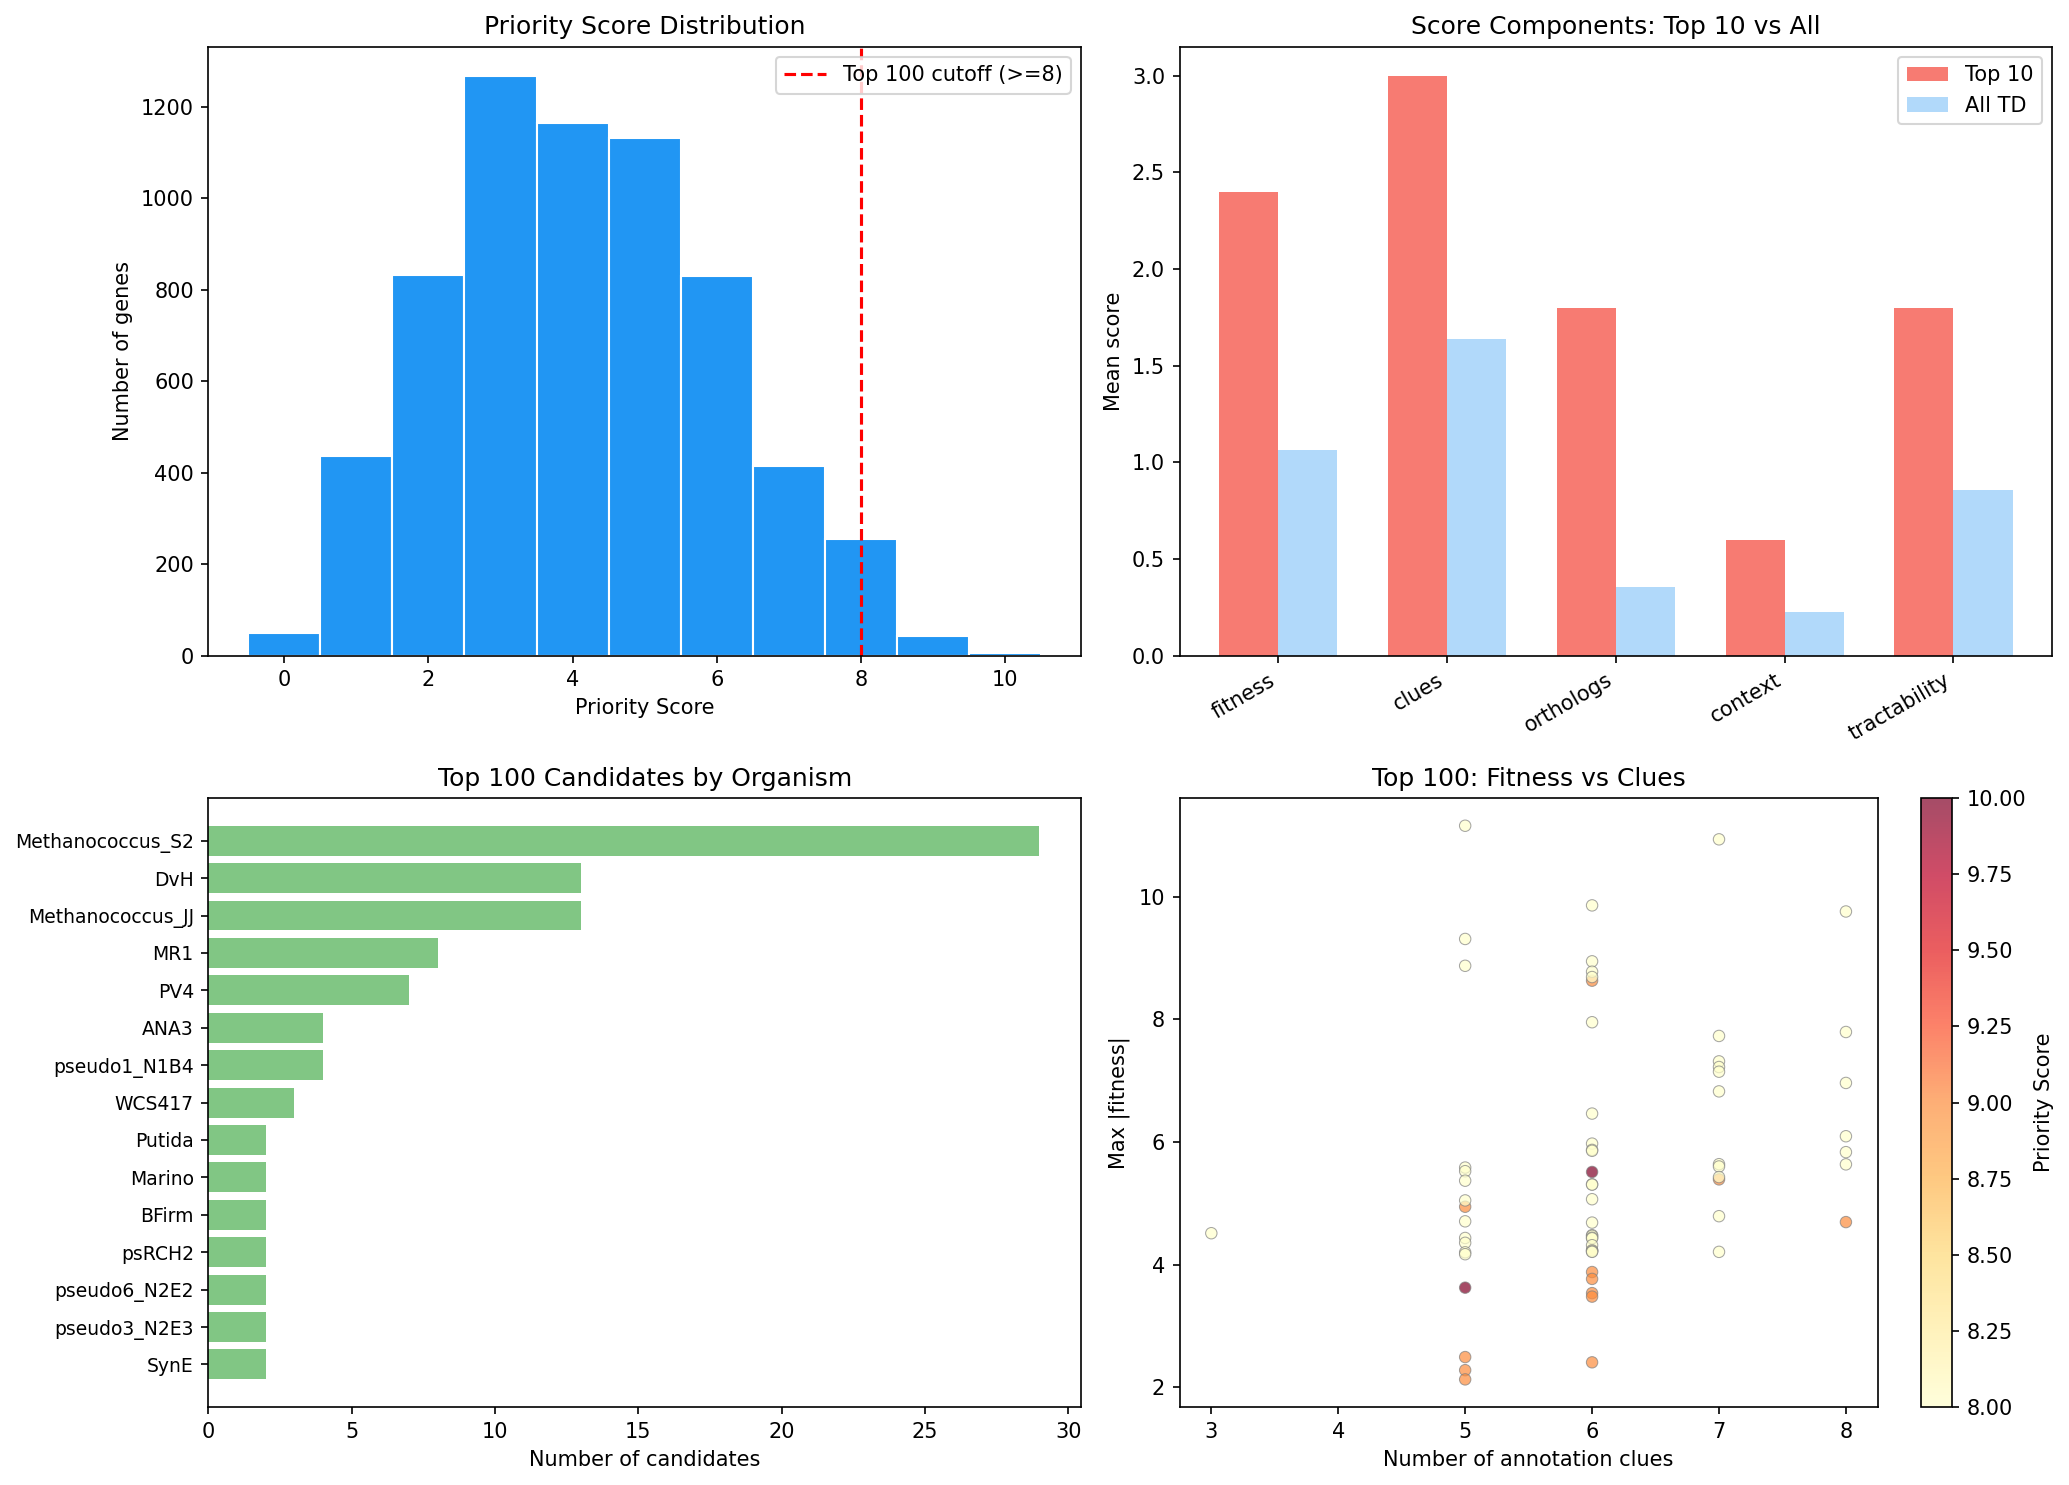

Saved: fig09_prioritization.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: priority score distribution
ax = axes[0, 0]
ax.hist(candidates['priority_score'], bins=range(0, candidates['priority_score'].max() + 2),
        color='#2196F3', edgecolor='white', align='left')
ax.axvline(top100.iloc[-1]['priority_score'], color='red', ls='--', 
           label=f'Top 100 cutoff (>={top100.iloc[-1]["priority_score"]})')
ax.set_xlabel('Priority Score')
ax.set_ylabel('Number of genes')
ax.set_title('Priority Score Distribution')
ax.legend()

# Top-right: score component radar for top 10 vs all
ax = axes[0, 1]
top10_means = top50.head(10)[score_cols].mean()
all_means = candidates[score_cols].mean()
x = range(len(score_cols))
width = 0.35
ax.bar([i - width/2 for i in x], top10_means, width, label='Top 10', color='#f44336', alpha=0.7)
ax.bar([i + width/2 for i in x], all_means, width, label='All TD', color='#90CAF9', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('score_', '') for c in score_cols], rotation=30, ha='right')
ax.set_ylabel('Mean score')
ax.set_title('Score Components: Top 10 vs All')
ax.legend()

# Bottom-left: organism distribution of top 100
ax = axes[1, 0]
org_top = org_dist.head(15)
ax.barh(range(len(org_top)), org_top.values, color='#4CAF50', alpha=0.7)
ax.set_yticks(range(len(org_top)))
ax.set_yticklabels(org_top.index, fontsize=9)
ax.set_xlabel('Number of candidates')
ax.set_title('Top 100 Candidates by Organism')
ax.invert_yaxis()

# Bottom-right: fitness vs clue count for top 100
ax = axes[1, 1]
scatter = ax.scatter(top100['n_clues'], top100['max_abs_fit'],
                     c=top100['priority_score'], cmap='YlOrRd', 
                     s=30, alpha=0.7, edgecolors='gray', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='Priority Score')
ax.set_xlabel('Number of annotation clues')
ax.set_ylabel('Max |fitness|')
ax.set_title('Top 100: Fitness vs Clues')

plt.tight_layout()
plt.savefig(f'{FIG}/fig09_prioritization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig09_prioritization.png')

## 6. Unlinked Dark Genes Gap Assessment

In [8]:
# The 17,479 unlinked dark genes couldn't be assessed by bakta
unlinked = pd.read_csv(f'{OUT}/unlinked_dark_genes.tsv', sep='\t')
print(f'Unlinked dark genes: {len(unlinked):,}')
print(f'  Organisms: {unlinked["orgId"].nunique()}')

# Estimate what fraction might be truly dark
# Among linked genes: 6,427 / (6,427 + 33,105) = 16.3% are truly dark
td_frac = len(td) / (len(td) + 33105)
est_unlinked_td = int(len(unlinked) * td_frac)
print(f'\nEstimated truly dark among unlinked (at {td_frac*100:.1f}% rate): ~{est_unlinked_td:,}')
print(f'Total estimated truly dark: {len(td) + est_unlinked_td:,}')
print(f'  (our ranked list covers {len(td) / (len(td) + est_unlinked_td) * 100:.0f}% of estimated total)')

# Strong fitness unlinked genes
if 'max_abs_fit' in unlinked.columns:
    unlinked_strong = unlinked[unlinked['max_abs_fit'] >= 2.0]
    print(f'\nUnlinked with strong fitness (|f| >= 2): {len(unlinked_strong):,} ({len(unlinked_strong)/len(unlinked)*100:.1f}%)')
    print(f'These could include high-priority candidates not in our ranked list')

Unlinked dark genes: 17,479
  Organisms: 48

Estimated truly dark among unlinked (at 16.3% rate): ~2,841
Total estimated truly dark: 9,268
  (our ranked list covers 69% of estimated total)

Unlinked with strong fitness (|f| >= 2): 2,208 (12.6%)
These could include high-priority candidates not in our ranked list


## 7. Save and Summary

In [9]:
# Save full ranked list
save_cols = ['orgId', 'locusId', 'gene_cluster_id', 'priority_score',
             'score_fitness', 'score_clues', 'score_orthologs', 'score_context', 'score_tractability',
             'max_abs_fit', 'top_condition_class', 'est_aa_length',
             'is_essential_dark', 'n_clues', 'tier', 'pfam_class',
             'has_uniref50', 'has_pfam', 'has_eggnog', 'has_cog', 'has_orthologs', 'in_module',
             'n_ortholog_orgs', 'near_mobile_element', 'in_operon', 'max_cofitness']
# Only include columns that exist
save_cols = [c for c in save_cols if c in candidates.columns]
candidates[save_cols].to_csv(f'{OUT}/prioritized_truly_dark_candidates.tsv', sep='\t', index=False)
print(f'Saved: prioritized_truly_dark_candidates.tsv')

# Save top 100 with hypotheses
top100_out = candidates.head(100).copy()
top100_out['hypothesis'] = top100_out.apply(build_hypothesis, axis=1)
top100_save = save_cols + ['hypothesis']
top100_save = [c for c in top100_save if c in top100_out.columns]
top100_out[top100_save].to_csv(f'{OUT}/top100_candidates.tsv', sep='\t', index=False)
print(f'Saved: top100_candidates.tsv')

print(f'\n{"=" * 60}')
print(f'=== NB06 Complete: Experimental Prioritization ===')
print(f'{"=" * 60}')
print(f'\nFrom {len(td):,} truly dark genes → {len(top100):,} top candidates')
print(f'  Score range: {top100["priority_score"].min()}-{top100["priority_score"].max()}')
print(f'  Organisms represented: {top100["orgId"].nunique()}')
print(f'  Essential: {(top100["is_essential_dark"].fillna(False)).sum()}')
print(f'  With Pfam: {top100["has_pfam"].sum()}')
print(f'  In operons: {top100["in_operon"].fillna(False).sum()}')
print(f'  In ICA modules: {top100["in_module"].sum()}')
print(f'\nHypothesis summary:')
print(f'  H1 (structurally distinct): SUPPORTED — shorter, less conserved, lower GC')
print(f'  H2 (stress enrichment): REJECTED — depleted in stress (OR=0.53)')
print(f'  H3 (accessory/HGT): SUPPORTED — 4.2x fewer orthologs, higher GC deviation')
print(f'  H4 (partial clues): SUPPORTED — 96% have >= 1 clue, 11% have partial function')
print(f'\nGap: ~{est_unlinked_td:,} estimated truly dark genes in unlinked set (not ranked)')
print(f'\nReady for /synthesize')

Saved: prioritized_truly_dark_candidates.tsv
Saved: top100_candidates.tsv

=== NB06 Complete: Experimental Prioritization ===

From 6,427 truly dark genes → 100 top candidates
  Score range: 8-10
  Organisms represented: 19
  Essential: 34
  With Pfam: 17
  In operons: 53
  In ICA modules: 30

Hypothesis summary:
  H1 (structurally distinct): SUPPORTED — shorter, less conserved, lower GC
  H2 (stress enrichment): REJECTED — depleted in stress (OR=0.53)
  H3 (accessory/HGT): SUPPORTED — 4.2x fewer orthologs, higher GC deviation
  H4 (partial clues): SUPPORTED — 96% have >= 1 clue, 11% have partial function

Gap: ~2,841 estimated truly dark genes in unlinked set (not ranked)

Ready for /synthesize
